# Practice 1: PyTorch FashionMNIST Classification

## MLP vs CNN (v2) — Baseline → Mixup → Ensemble

| Step | Description | What it does | Import path |
|------|-------------|--------------|-------------|
| 1 | Import Libraries | Load PyTorch, src modules, detect device | — |
| 2 | Load Dataset | Download FashionMNIST + transforms | `src/data_utils.py` |
| 3 | Explore Dataset | Shape, class distribution, pixel stats | `src/vis_utils.py` |
| 4 | Create DataLoaders | Split into train/test batches | `src/data_utils.py` |
| 5 | Define Models (v2) | MLPv2 (BatchNorm) vs CNNv2 (3 conv + BN) | — |
| 6 | Train Baseline | 50 epochs, label smoothing, scheduler | `src/train_utils.py` |
| 7 | Compare: Loss Curves | Loss curves of MLP + CNN | `src/vis_utils.py` |
| 8 | Compare: Confusion Matrices | Per-class TPR/FPR/Precision + heatmaps | `src/eval_utils.py` |
| 9 | Compare: ROC Curves | Per-class ROC curves + AUC scores | `src/eval_utils.py` + `src/vis_utils.py` |
| 10 | Compare: PR Curves | Per-class Precision-Recall curves + AP | `src/eval_utils.py` + `src/vis_utils.py` |
| 11 | Summary Table | Accuracy / ROC-AUC / PR-AUC / Params | `src/eval_utils.py` |
| 12 | Save Baseline Models | Save .pth weights | `src/model_utils.py` |
| 13 | Baseline Predictions | Predicted vs actual images | `src/vis_utils.py` |
| 14 | Baseline Error Analysis | Wrong predictions + deep dive | `src/vis_utils.py` + `src/eval_utils.py` |
| 15 | Mixup Augmentation | Blend images + labels linearly | `src/aug_utils.py` |
| 16 | Train with Mixup | Re-train both with Mixup (alpha=0.2) | `src/train_utils.py` |
| 17 | Ensemble Evaluation | Average MLP + CNN outputs | `src/eval_utils.py` |

---

## 1. Import Libraries

Import `src/` utility modules, PyTorch core, and auto-detect device (MPS > CUDA > CPU).

In [1]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from src.data_utils import get_fashionmnist_transforms, get_augmented_transforms, load_fashionmnist, get_dataloaders
from src.vis_utils import explore_dataset, plot_losses, plot_confusion_matrix
from src.vis_utils import plot_roc_curves, plot_pr_curves, plot_predictions, plot_misclassified
from src.model_utils import save_model
from src.train_utils import train_model
from src.eval_utils import evaluate_detailed, get_all_probas_and_labels, ensemble_evaluate
from src.eval_utils import compute_roc_auc_scores, compute_pr_auc_scores
from src.eval_utils import print_comparison_table, analyze_errors, weak_class_report
from src.aug_utils import visualize_mixup

print(f"PyTorch version: {torch.__version__}")
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

PyTorch version: 2.8.0
Using device: mps


## 2. Load Dataset

Download FashionMNIST (60k train / 10k test).

Train: RandomRotation(15°), RandomAffine(0.08), ColorJitter(0.25), RandomErasing(p=0.25).

Test: `ToTensor()` + `Normalize(0.5, 0.5)` only.

In [2]:
test_transform = get_fashionmnist_transforms()
train_transform = get_augmented_transforms()
train_dataset, test_dataset = load_fashionmnist(test_transform, train_transform=train_transform)

## 3. Explore Dataset

Print basic info (classes, shape), show 10 clean (non-augmented) sample images, class distribution, and pixel intensity histogram.

Number of classes: 10
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Train samples: 60000
Image shape: torch.Size([1, 28, 28])


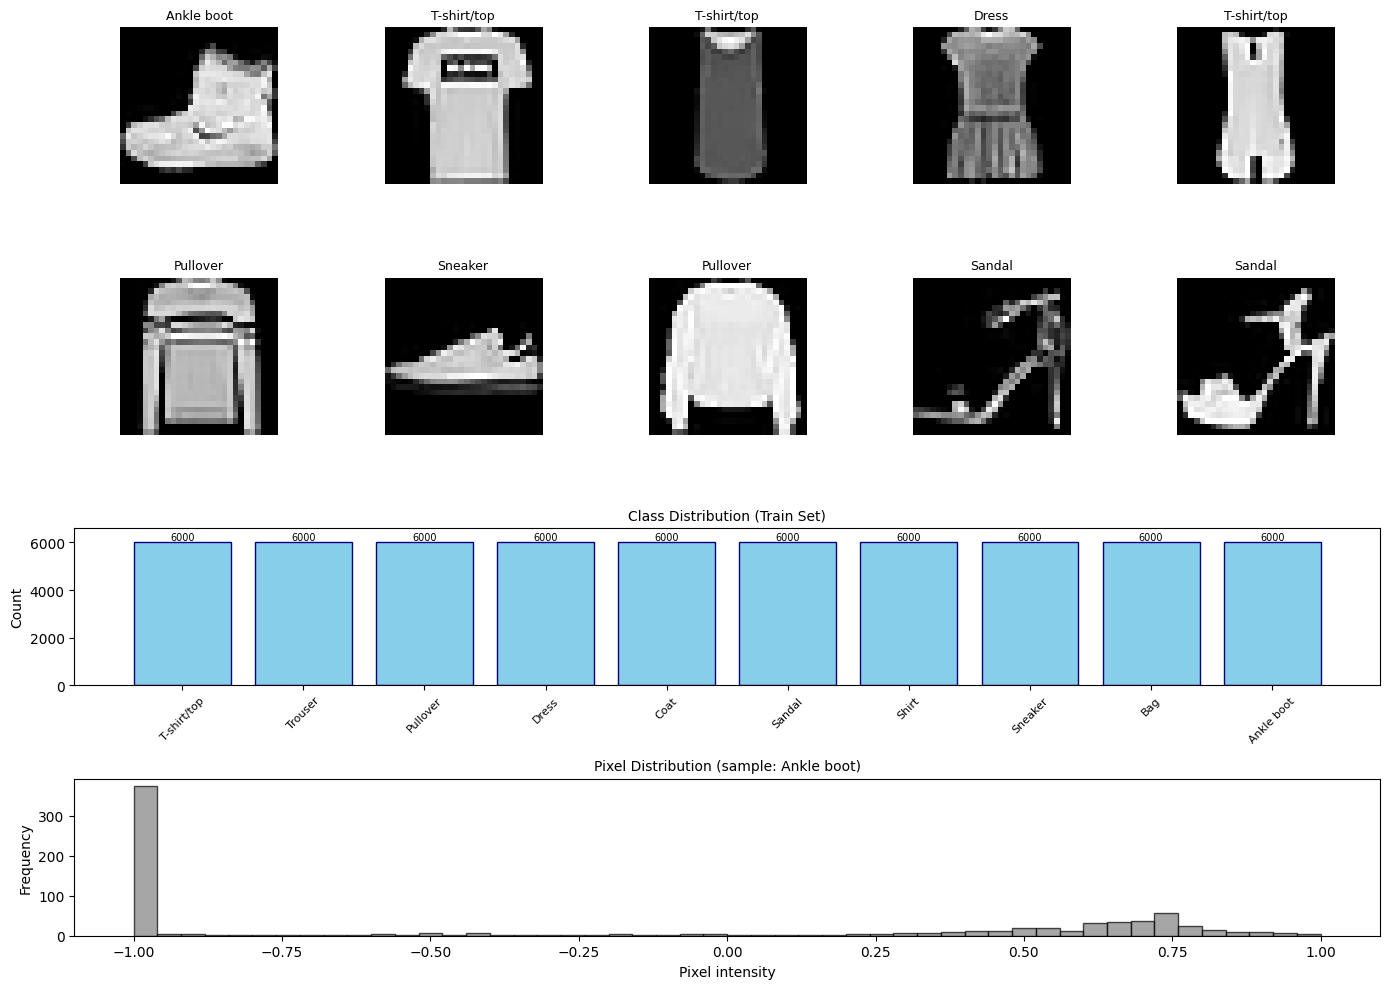

Image tensor shape: torch.Size([1, 28, 28])
Image tensor dtype: torch.float32
Pixel value range: [-1.0000, 1.0000]
Mean pixel value: -0.2372
Std pixel value: 0.7989


In [3]:
class_names = train_dataset.classes
clean_train, _ = load_fashionmnist(test_transform)
explore_dataset(clean_train, class_names)

## 4. Create DataLoaders

Batch size = 128. Train loader shuffles, test loader does not.

In [4]:
train_loader, test_loader = get_dataloaders(train_dataset, test_dataset, batch_size=128)
print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 469
Test batches: 79


## 5. Define Models (v2)

**MLPv2:** `784 -> 512 -> 256 -> 128 -> 10`, BatchNorm1d, ReLU, Dropout(0.3).

**CNNv2:** 3 conv blocks with BatchNorm2d: `Conv(1→32)→BN→ReLU→Pool → Conv(32→64)→BN→ReLU→Pool → Conv(64→128)→BN→ReLU→Pool → FC(128*3*3→128)→Dropout→10`.

In [5]:
class MLP_v2(nn.Module):
    def __init__(self, input_size=784, num_classes=10, dropout=0.3):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.out = nn.Linear(128, num_classes)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout(self.relu(self.bn1(self.fc1(x))))
        x = self.dropout(self.relu(self.bn2(self.fc2(x))))
        x = self.dropout(self.relu(self.bn3(self.fc3(x))))
        return self.out(x)


class CNN_v2(nn.Module):
    def __init__(self, num_classes=10, dropout=0.3):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.bn_fc = nn.BatchNorm1d(128)
        self.out = nn.Linear(128, num_classes)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.bn_fc(self.fc1(x))))
        return self.out(x)


model_mlp = MLP_v2().to(device)
model_cnn = CNN_v2().to(device)

mlp_params = sum(p.numel() for p in model_mlp.parameters())
cnn_params = sum(p.numel() for p in model_cnn.parameters())
print(f'MLP_v2 params: {mlp_params:,}')
print(f'CNN_v2 params: {cnn_params:,}')

MLP_v2 params: 569,226
CNN_v2 params: 242,250


## 6. Train Baseline

`CrossEntropyLoss(label_smoothing=0.1)`, `AdamW(weight_decay=1e-4)`, 50 epochs, `CosineAnnealingLR`.

In [6]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
num_epochs = 50

print('--- Training MLP_v2 ---')
optimizer_mlp = optim.AdamW(model_mlp.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_mlp = optim.lr_scheduler.CosineAnnealingLR(optimizer_mlp, T_max=num_epochs)
train_losses_mlp = train_model(model_mlp, train_loader, criterion, optimizer_mlp, device,
                                num_epochs=num_epochs, scheduler=scheduler_mlp)

print('\n--- Training CNN_v2 ---')
optimizer_cnn = optim.AdamW(model_cnn.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_cnn = optim.lr_scheduler.CosineAnnealingLR(optimizer_cnn, T_max=num_epochs)
train_losses_cnn = train_model(model_cnn, train_loader, criterion, optimizer_cnn, device,
                                num_epochs=num_epochs, scheduler=scheduler_cnn)

--- Training MLP_v2 ---
Epoch [1/50], Loss: 1.2073, LR: 9.99e-04
Epoch [2/50], Loss: 1.0998, LR: 9.96e-04
Epoch [3/50], Loss: 1.0652, LR: 9.91e-04
Epoch [4/50], Loss: 1.0464, LR: 9.84e-04
Epoch [5/50], Loss: 1.0279, LR: 9.76e-04
Epoch [6/50], Loss: 1.0181, LR: 9.65e-04
Epoch [7/50], Loss: 1.0089, LR: 9.52e-04
Epoch [8/50], Loss: 1.0009, LR: 9.38e-04
Epoch [9/50], Loss: 0.9934, LR: 9.22e-04
Epoch [10/50], Loss: 0.9838, LR: 9.05e-04
Epoch [11/50], Loss: 0.9814, LR: 8.85e-04
Epoch [12/50], Loss: 0.9743, LR: 8.64e-04
Epoch [13/50], Loss: 0.9705, LR: 8.42e-04
Epoch [14/50], Loss: 0.9645, LR: 8.19e-04
Epoch [15/50], Loss: 0.9594, LR: 7.94e-04
Epoch [16/50], Loss: 0.9566, LR: 7.68e-04
Epoch [17/50], Loss: 0.9540, LR: 7.41e-04
Epoch [18/50], Loss: 0.9499, LR: 7.13e-04
Epoch [19/50], Loss: 0.9487, LR: 6.84e-04
Epoch [20/50], Loss: 0.9398, LR: 6.55e-04
Epoch [21/50], Loss: 0.9364, LR: 6.24e-04
Epoch [22/50], Loss: 0.9400, LR: 5.94e-04
Epoch [23/50], Loss: 0.9325, LR: 5.63e-04
Epoch [24/50], Loss

## 7. Compare: Loss Curves

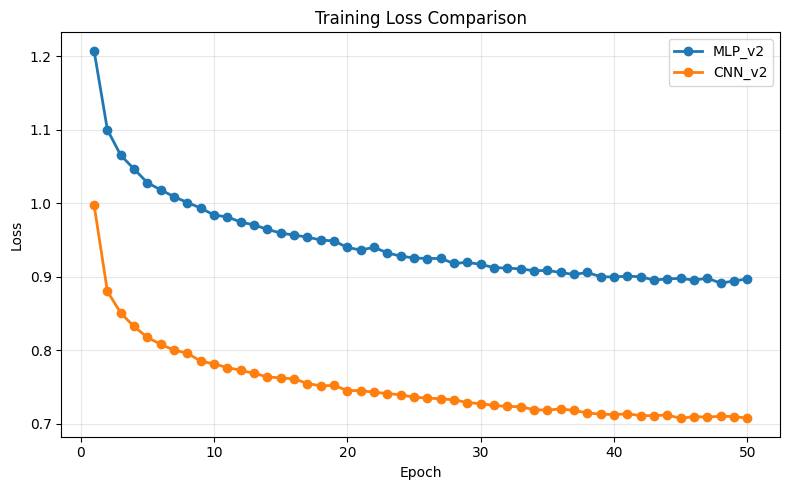

In [7]:
plot_losses({'MLP_v2': train_losses_mlp, 'CNN_v2': train_losses_cnn})

## 8. Compare: Confusion Matrices

  Test Accuracy: 87.45%
  Class           TPR(Recall)        FPR  Precision
  ---------------------------------------------
  T-shirt/top         0.8450     0.0278     0.7717
  Trouser             0.9750     0.0017     0.9848
  Pullover            0.7910     0.0227     0.7950
  Dress               0.8820     0.0138     0.8767
  Coat                0.8180     0.0268     0.7724
  Sandal              0.9530     0.0029     0.9734
  Shirt               0.5870     0.0270     0.7072
  Sneaker             0.9620     0.0082     0.9286
  Bag                 0.9720     0.0044     0.9605
  Ankle boot          0.9600     0.0042     0.9619


  Test Accuracy: 93.15%
  Class           TPR(Recall)        FPR  Precision
  ---------------------------------------------
  T-shirt/top         0.8980     0.0128     0.8865
  Trouser             0.9920     0.0010     0.9910
  Pullover            0.8860     0.0113     0.8968
  Dress               0.9240     0.0072     0.9343
  Coat                0.9170     0.0

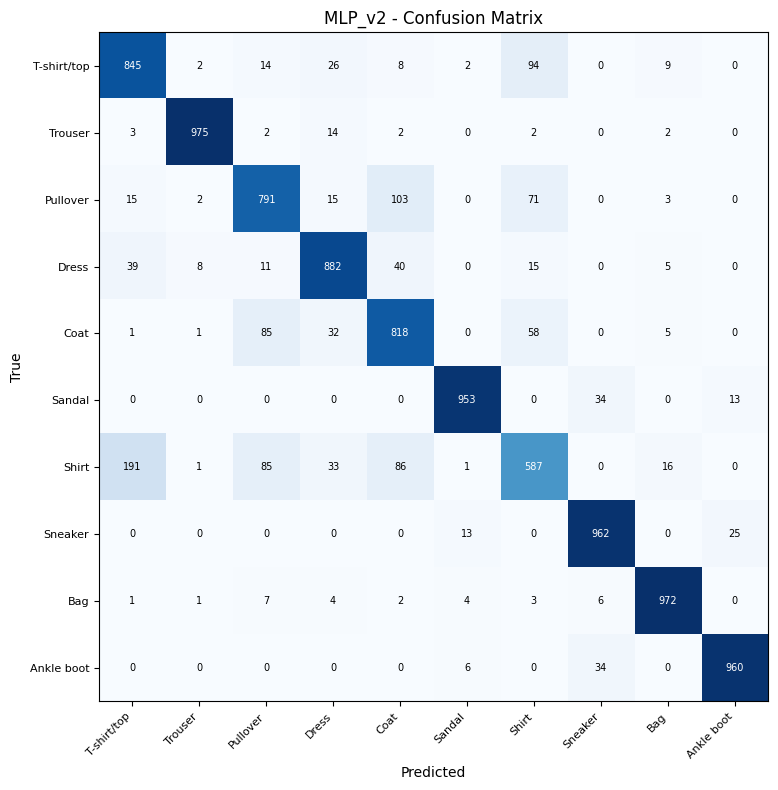

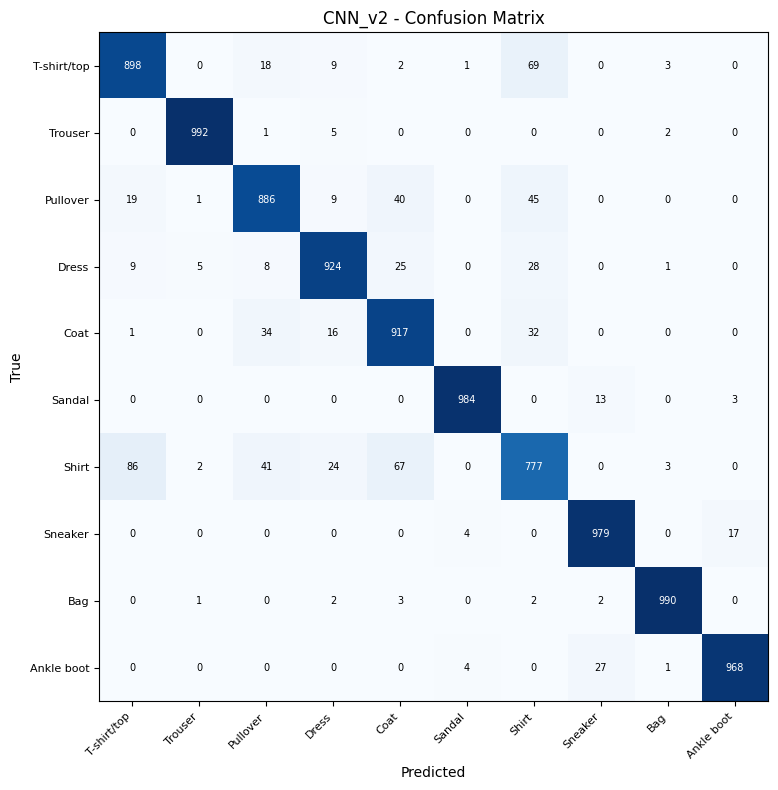

In [8]:
acc_mlp, cm_mlp, _ = evaluate_detailed(model_mlp, test_loader, device, class_names)
print('\n')
acc_cnn, cm_cnn, _ = evaluate_detailed(model_cnn, test_loader, device, class_names)

plot_confusion_matrix(cm_mlp, class_names, title='MLP_v2 - Confusion Matrix',
                      save_path='../outputs/plots/confusion_matrix_mlp.png')
plot_confusion_matrix(cm_cnn, class_names, title='CNN_v2 - Confusion Matrix',
                      save_path='../outputs/plots/confusion_matrix_cnn.png')

## 9. Compare: ROC Curves

MLP macro ROC-AUC: 0.9895
CNN macro ROC-AUC: 0.9958


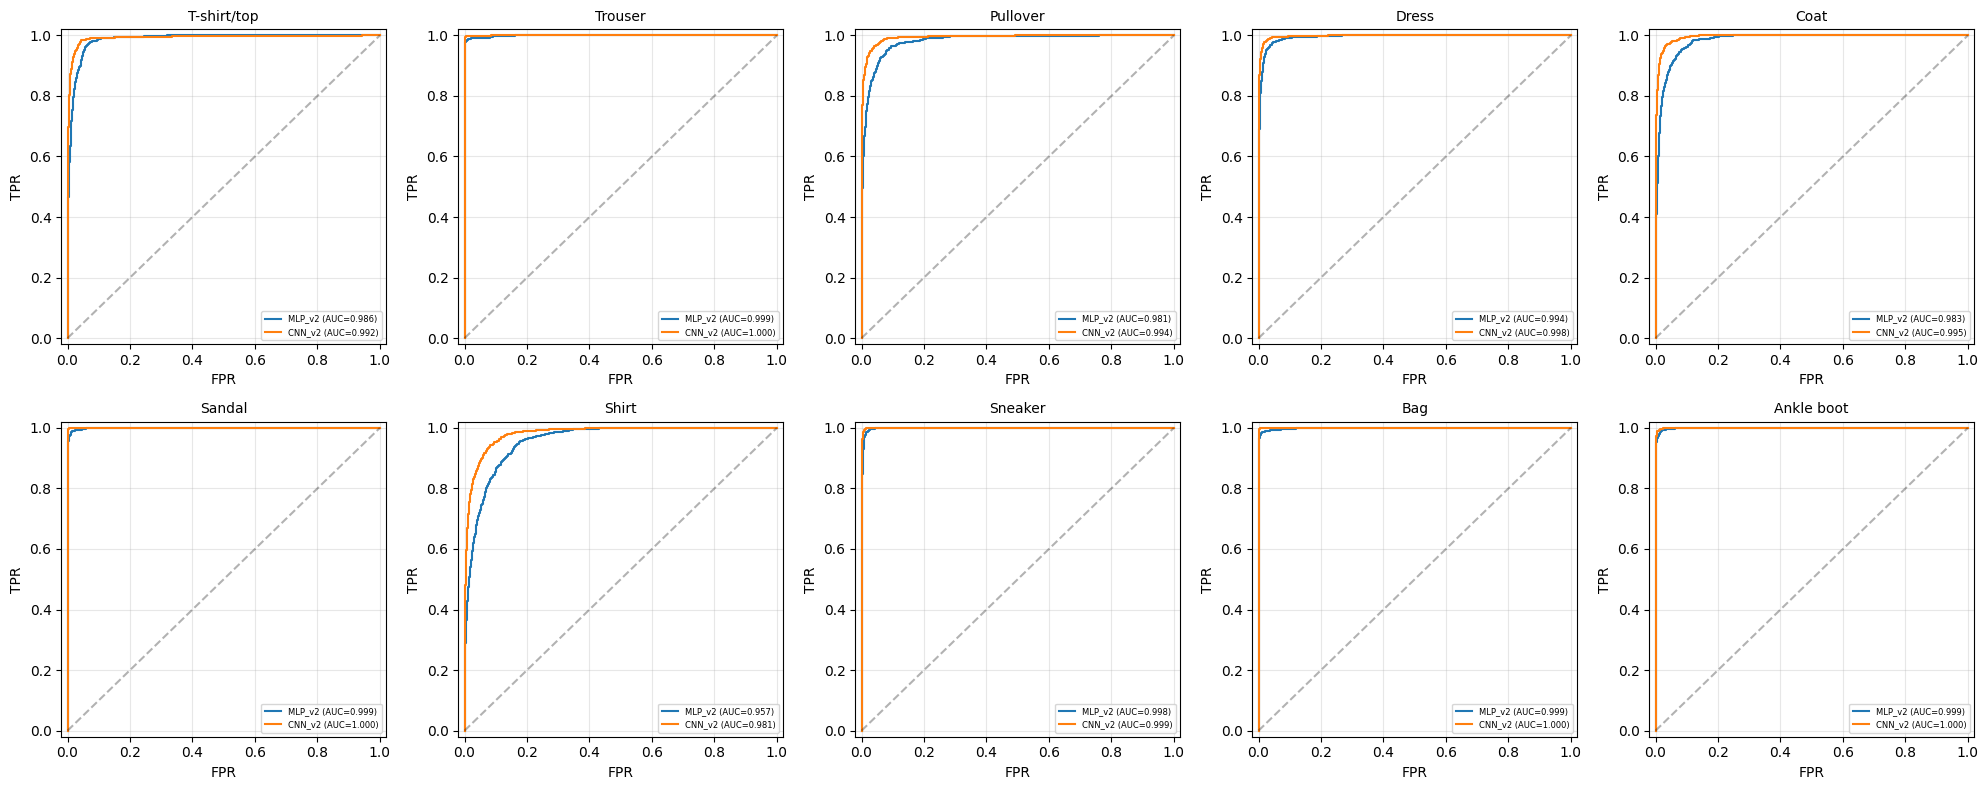

In [9]:
probas_mlp, labels = get_all_probas_and_labels(model_mlp, test_loader, device, 10)
probas_cnn, _ = get_all_probas_and_labels(model_cnn, test_loader, device, 10)

roc_mlp = compute_roc_auc_scores(probas_mlp, labels)
roc_cnn = compute_roc_auc_scores(probas_cnn, labels)
print(f'MLP macro ROC-AUC: {roc_mlp["macro"]:.4f}')
print(f'CNN macro ROC-AUC: {roc_cnn["macro"]:.4f}')
plot_roc_curves({'MLP_v2': probas_mlp, 'CNN_v2': probas_cnn}, labels, class_names)

## 10. Compare: PR Curves

MLP macro PR-AUC: 0.9299
CNN macro PR-AUC: 0.9731


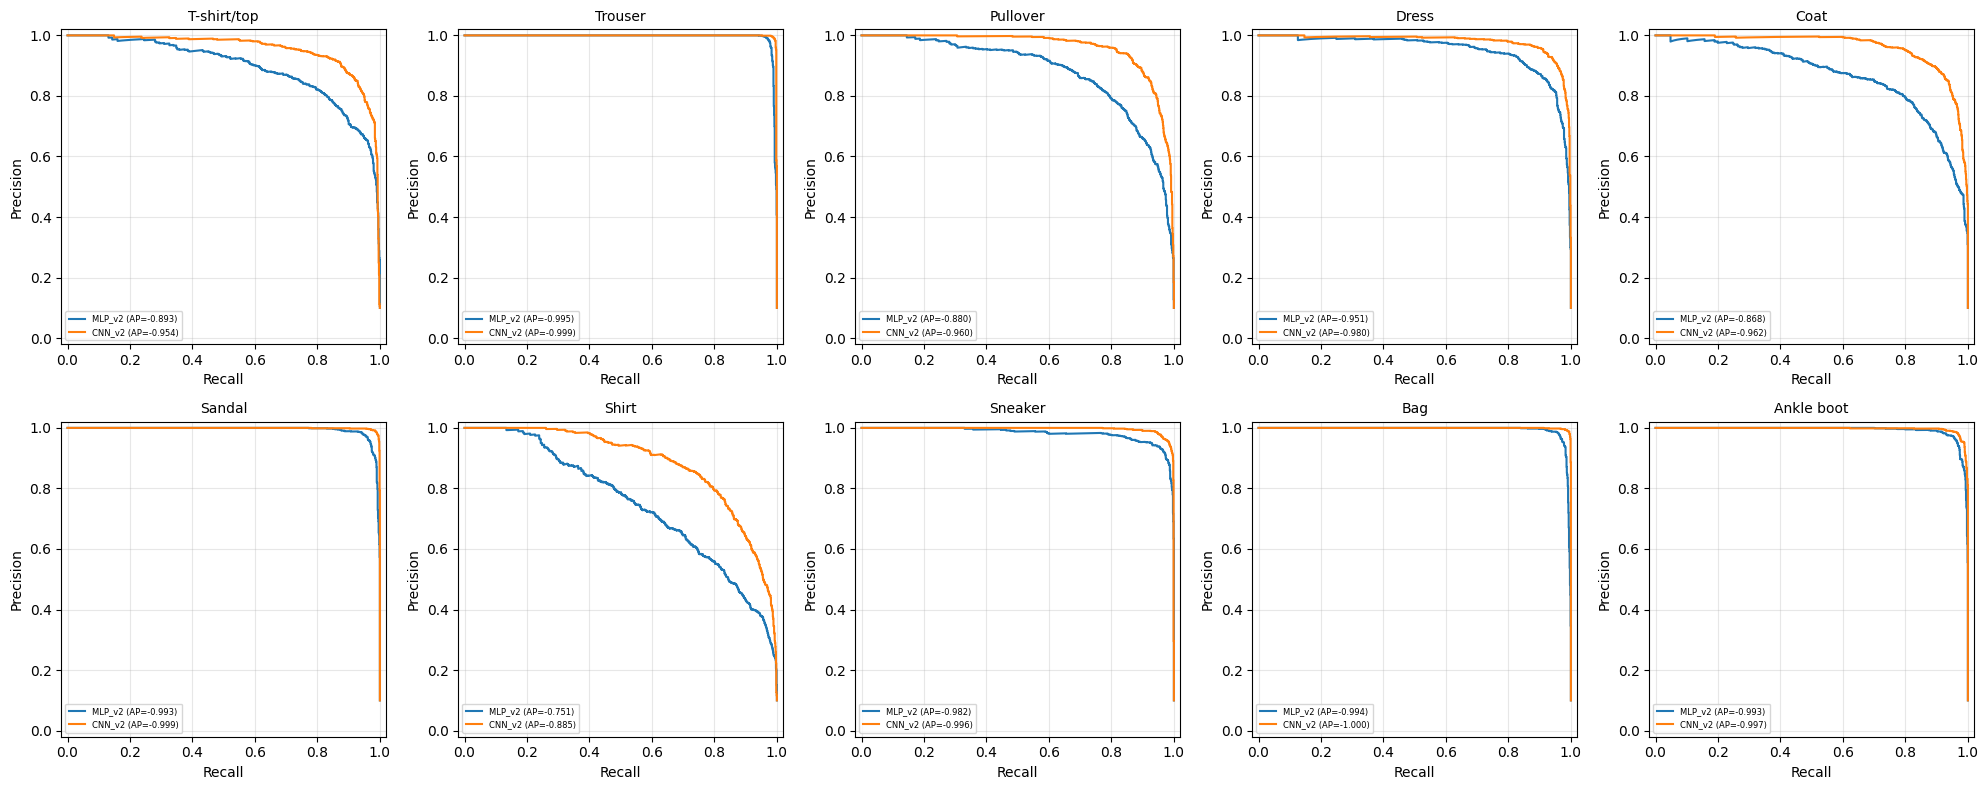

In [10]:
pr_mlp = compute_pr_auc_scores(probas_mlp, labels)
pr_cnn = compute_pr_auc_scores(probas_cnn, labels)
print(f'MLP macro PR-AUC: {pr_mlp["macro"]:.4f}')
print(f'CNN macro PR-AUC: {pr_cnn["macro"]:.4f}')
plot_pr_curves({'MLP_v2': probas_mlp, 'CNN_v2': probas_cnn}, labels, class_names)

## 11. Summary Table

In [11]:
print_comparison_table(acc_mlp, acc_cnn, roc_mlp, roc_cnn, pr_mlp, pr_cnn,
                       mlp_params, cnn_params, class_names)

Metric                             MLP          CNN         Diff
---------------------------------------------------------------------------
Test Accuracy (%)               87.45       93.15       +5.70
Macro ROC-AUC                  0.9895      0.9958     +0.0063
Macro PR-AUC (AP)              0.9299      0.9731     +0.0432
Parameters                    569,226     242,250    -326,976

Per-class ROC-AUC                  MLP          CNN
--------------------------------------------------
T-shirt/top                    0.9865      0.9923
Trouser                        0.9990      0.9998
Pullover                       0.9815      0.9937
Dress                          0.9936      0.9975
Coat                           0.9825      0.9950
Sandal                         0.9991      0.9999
Shirt                          0.9565      0.9807
Sneaker                        0.9982      0.9994
Bag                            0.9988      0.9999
Ankle boot                     0.9990      0.9996

Per-cl

## 12. Save Baseline Models

In [12]:
save_model(model_mlp, '../outputs/model/mlp_v2.pth')
save_model(model_cnn, '../outputs/model/cnn_v2.pth')

Model saved to ../outputs/model/mlp_v2.pth
Model saved to ../outputs/model/cnn_v2.pth


## 13. Baseline Predictions

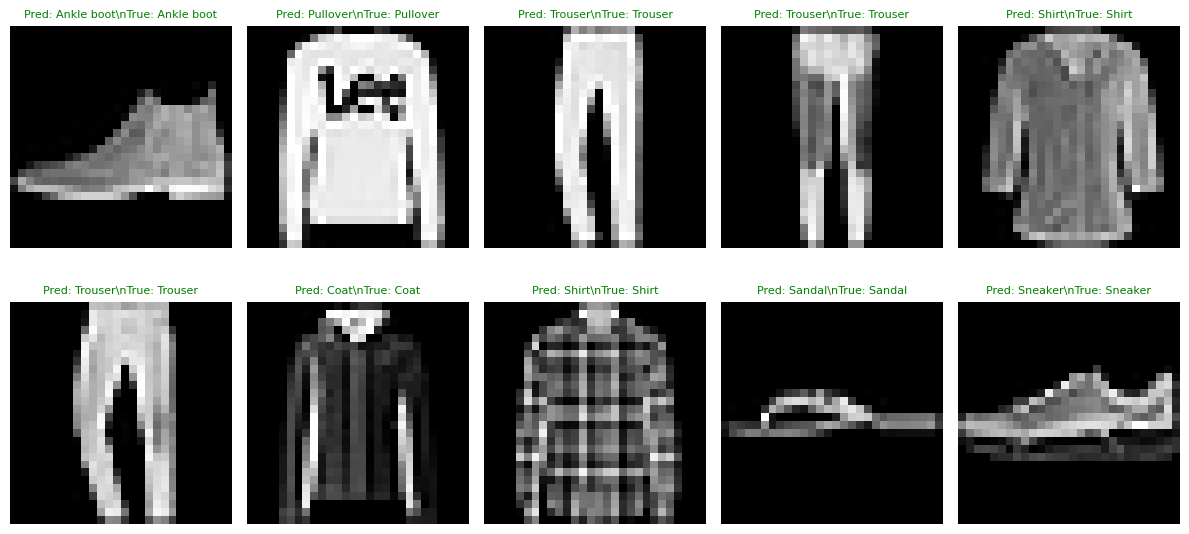

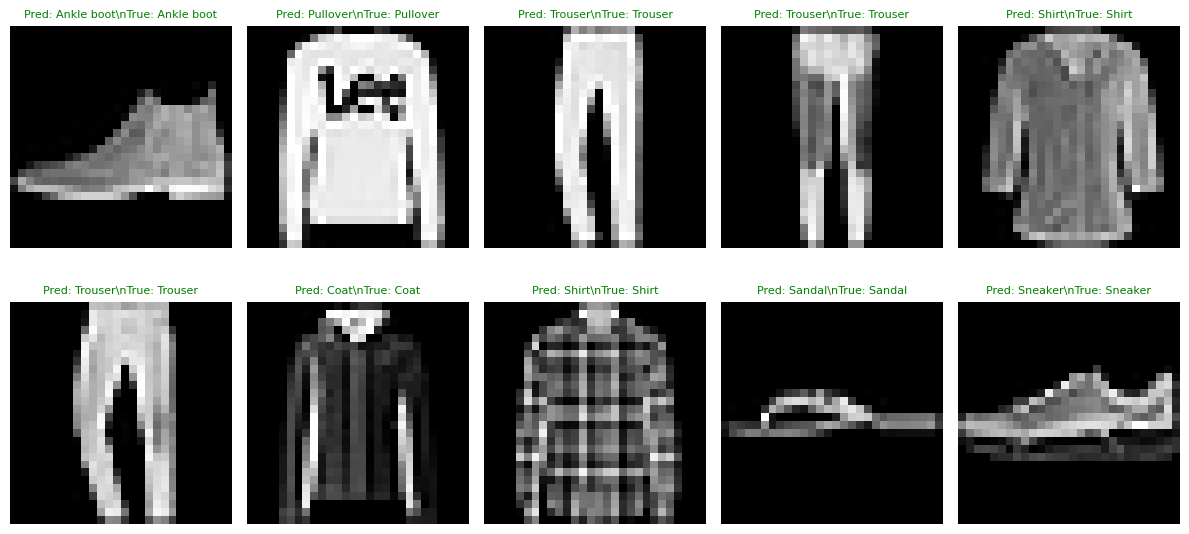

In [13]:
plot_predictions(model_mlp, test_loader, class_names, device,
               '../outputs/plots/predictions_mlp.png')
plot_predictions(model_cnn, test_loader, class_names, device,
               '../outputs/plots/predictions_cnn.png')

## 14. Baseline Error Analysis

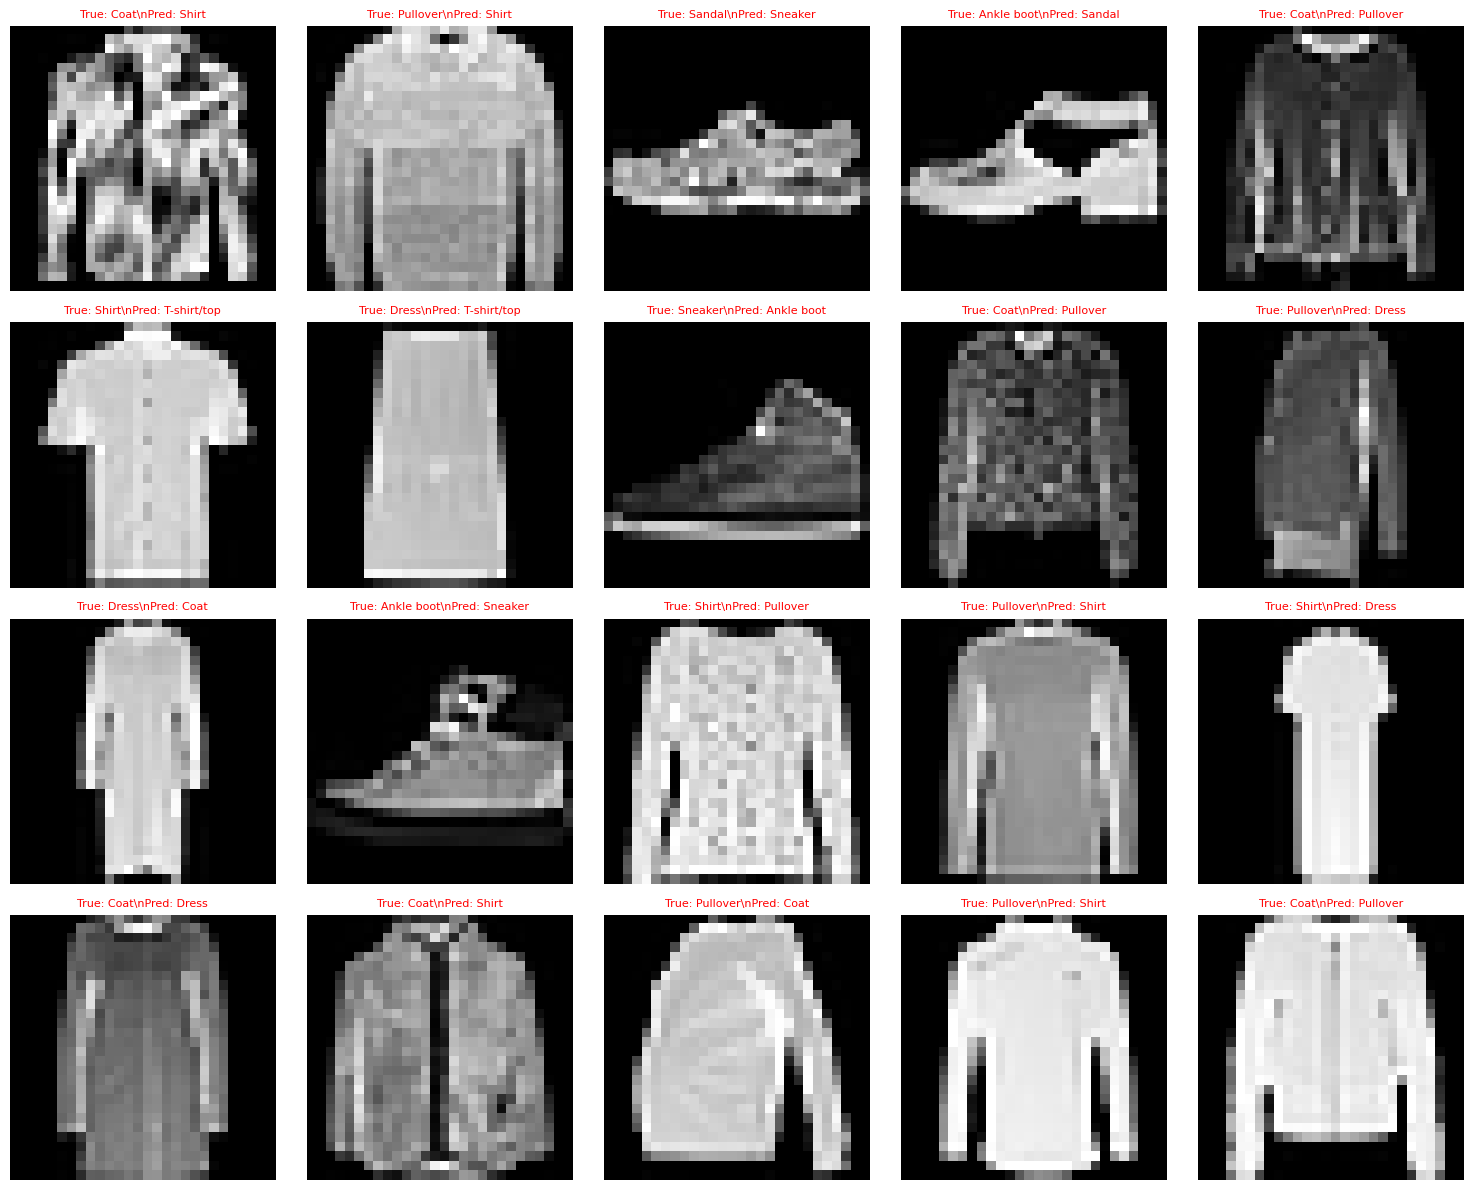

Displayed 20 misclassified samples.


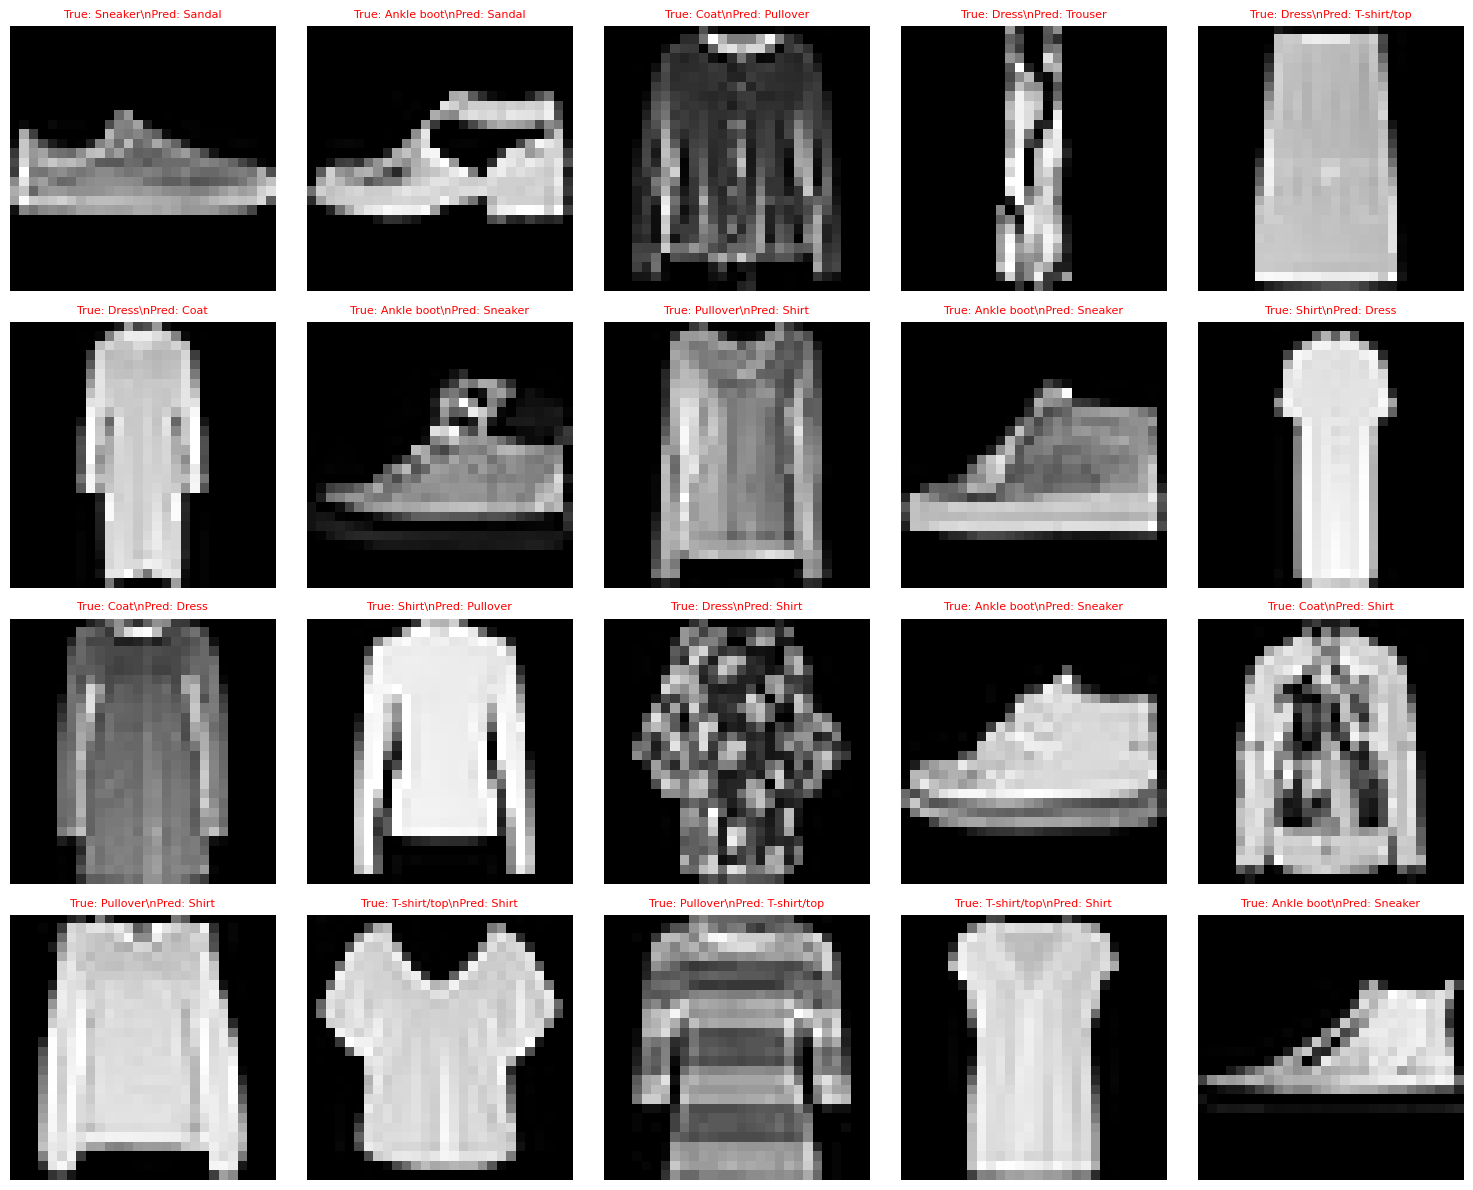

Displayed 20 misclassified samples.
--- MLP Baseline Error Analysis ---
  Error Analysis — Total misclassifications: 1255 / 10000
  Error rate: 12.55%

  Per-class errors (most to least):
  Class             Errors  Error % Top confused as                         
  ------------------------------------------------------------------------
  Shirt                413    41.3%  T-shirt/top (191), Coat (86), Pullover (85), Dress (33), Bag (16)
  Pullover             209    20.9%  Coat (103), Shirt (71), Dress (15), T-shirt/top (15), Bag (3)
  Coat                 182    18.2%  Pullover (85), Shirt (58), Dress (32), Bag (5), Trouser (1)
  T-shirt/top          155    15.5%  Shirt (94), Dress (26), Pullover (14), Bag (9), Coat (8)
  Dress                118    11.8%  Coat (40), T-shirt/top (39), Shirt (15), Pullover (11), Trouser (8)
  Sandal                47     4.7%  Sneaker (34), Ankle boot (13)           
  Ankle boot            40     4.0%  Sneaker (34), Sandal (6)                
  Snea

In [14]:
plot_misclassified(model_mlp, test_loader, class_names, device, 20,
                   '../outputs/plots/misclassified_mlp.png')
plot_misclassified(model_cnn, test_loader, class_names, device, 20,
                   '../outputs/plots/misclassified_cnn.png')

print('--- MLP Baseline Error Analysis ---')
analyze_errors(cm_mlp, class_names)
print('\n--- MLP Baseline Weak Class Deep Dive ---')
weak_class_report(cm_mlp, class_names, error_threshold=0.08)

print('\n--- CNN Baseline Error Analysis ---')
analyze_errors(cm_cnn, class_names)
print('\n--- CNN Baseline Weak Class Deep Dive ---')
weak_class_report(cm_cnn, class_names, error_threshold=0.08)

## 15. Mixup Augmentation

Mixup trộn tuyến tính 2 ảnh + label: `mixed_x = λ*x1 + (1-λ)*x2`, λ ~ Beta(0.2, 0.2).

Giúp model nội suy giữa các class, giảm overfit, đặc biệt cải thiện các class yếu (Shirt/T-shirt/Pullover).

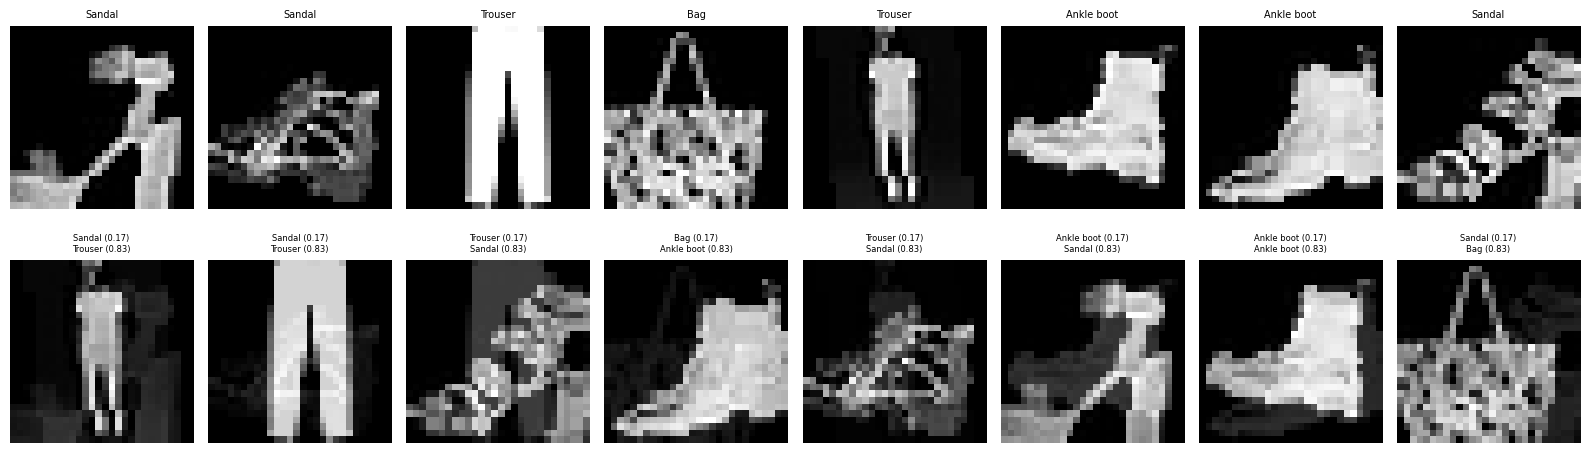

Mixup visualization saved to ../outputs/images/mixup_samples.png


In [15]:
visualize_mixup(train_loader, class_names, device, alpha=0.2, n_samples=8)

## 16. Train with Mixup

Khởi tạo model mới, train 50 epochs với Mixup(alpha=0.2). Cùng `CosineAnnealingLR`.

--- Training MLP_v2 with Mixup ---
Epoch [1/50], Loss: 1.4125, LR: 9.99e-04
Epoch [2/50], Loss: 1.3090, LR: 9.96e-04
Epoch [3/50], Loss: 1.2819, LR: 9.91e-04
Epoch [4/50], Loss: 1.2634, LR: 9.84e-04
Epoch [5/50], Loss: 1.2279, LR: 9.76e-04
Epoch [6/50], Loss: 1.2266, LR: 9.65e-04
Epoch [7/50], Loss: 1.2307, LR: 9.52e-04
Epoch [8/50], Loss: 1.2062, LR: 9.38e-04
Epoch [9/50], Loss: 1.2310, LR: 9.22e-04
Epoch [10/50], Loss: 1.2223, LR: 9.05e-04
Epoch [11/50], Loss: 1.2096, LR: 8.85e-04
Epoch [12/50], Loss: 1.1941, LR: 8.64e-04
Epoch [13/50], Loss: 1.1938, LR: 8.42e-04
Epoch [14/50], Loss: 1.1931, LR: 8.19e-04
Epoch [15/50], Loss: 1.1799, LR: 7.94e-04
Epoch [16/50], Loss: 1.1724, LR: 7.68e-04
Epoch [17/50], Loss: 1.1702, LR: 7.41e-04
Epoch [18/50], Loss: 1.1873, LR: 7.13e-04
Epoch [19/50], Loss: 1.1773, LR: 6.84e-04
Epoch [20/50], Loss: 1.1749, LR: 6.55e-04
Epoch [21/50], Loss: 1.1565, LR: 6.24e-04
Epoch [22/50], Loss: 1.1687, LR: 5.94e-04
Epoch [23/50], Loss: 1.1487, LR: 5.63e-04
Epoch [2

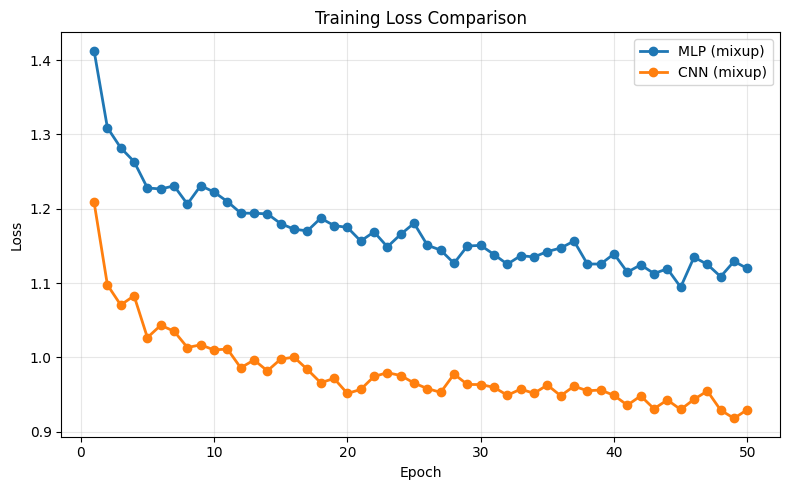

In [16]:
model_mlp_mx = MLP_v2().to(device)
model_cnn_mx = CNN_v2().to(device)

print('--- Training MLP_v2 with Mixup ---')
optimizer_mlp_mx = optim.AdamW(model_mlp_mx.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_mlp_mx = optim.lr_scheduler.CosineAnnealingLR(optimizer_mlp_mx, T_max=num_epochs)
losses_mlp_mx = train_model(model_mlp_mx, train_loader, criterion, optimizer_mlp_mx, device,
                            num_epochs=num_epochs, scheduler=scheduler_mlp_mx, use_mixup=True, alpha=0.2)

print('\n--- Training CNN_v2 with Mixup ---')
optimizer_cnn_mx = optim.AdamW(model_cnn_mx.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_cnn_mx = optim.lr_scheduler.CosineAnnealingLR(optimizer_cnn_mx, T_max=num_epochs)
losses_cnn_mx = train_model(model_cnn_mx, train_loader, criterion, optimizer_cnn_mx, device,
                            num_epochs=num_epochs, scheduler=scheduler_cnn_mx, use_mixup=True, alpha=0.2)

print('\n--- Mixup Loss Curves ---')
plot_losses({'MLP (mixup)': losses_mlp_mx, 'CNN (mixup)': losses_cnn_mx})

## 17. Ensemble Evaluation

Trung bình softmax của MLP + CNN → accuracy thường cao hơn từng model riêng lẻ 1-2%.

So sánh: MLP baseline vs CNN baseline vs MLP(mixup) vs CNN(mixup) vs Ensemble.

  Test Accuracy: 86.88%
  Class           TPR(Recall)        FPR  Precision
  ---------------------------------------------
  T-shirt/top         0.8470     0.0277     0.7728
  Trouser             0.9770     0.0024     0.9780
  Pullover            0.7580     0.0210     0.8004
  Dress               0.8850     0.0128     0.8850
  Coat                0.8390     0.0353     0.7252
  Sandal              0.9570     0.0034     0.9686
  Shirt               0.5400     0.0263     0.6950
  Sneaker             0.9580     0.0080     0.9301
  Bag                 0.9690     0.0048     0.9575
  Ankle boot          0.9580     0.0040     0.9638


  Test Accuracy: 92.66%
  Class           TPR(Recall)        FPR  Precision
  ---------------------------------------------
  T-shirt/top         0.8970     0.0153     0.8667
  Trouser             0.9910     0.0011     0.9900
  Pullover            0.9000     0.0149     0.8704
  Dress               0.9400     0.0088     0.9225
  Coat                0.8790     0.0

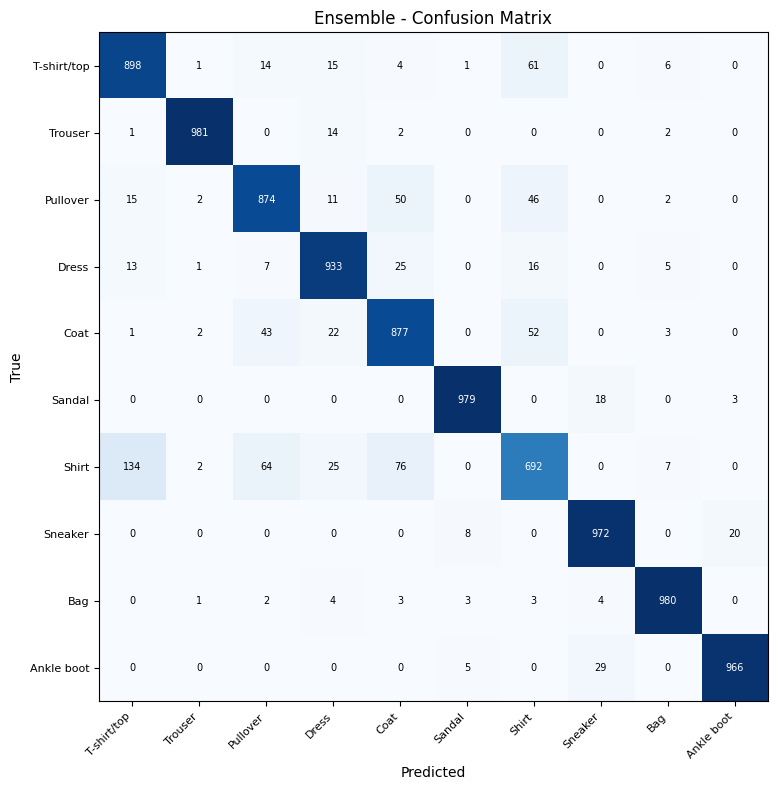


Approach                           Accuracy
---------------------------------------------
MLP_v2 (baseline)                    87.45%
CNN_v2 (baseline)                    93.15%
MLP_v2 (mixup)                       86.88%
CNN_v2 (mixup)                       92.66%
Ensemble (mixup MLP + CNN)           91.52%
Model saved to ../outputs/model/mlp_v2_mixup.pth
Model saved to ../outputs/model/cnn_v2_mixup.pth


In [17]:
# Evaluate Mixup-trained models individually
acc_mlp_mx, cm_mlp_mx, _ = evaluate_detailed(model_mlp_mx, test_loader, device, class_names)
print('\n')
acc_cnn_mx, cm_cnn_mx, _ = evaluate_detailed(model_cnn_mx, test_loader, device, class_names)

# Ensemble: average MLP(mixup) + CNN(mixup) probabilities
print('\n--- Ensemble (Mixup MLP + Mixup CNN) ---')
acc_ens, cm_ens, _, probas_ens, labels_ens = ensemble_evaluate(
    model_mlp_mx, model_cnn_mx, test_loader, device, class_names)

plot_confusion_matrix(cm_ens, class_names, title='Ensemble - Confusion Matrix',
                      save_path='../outputs/plots/confusion_matrix_ensemble.png')

# Summary: all 5 approaches
print(f'\n{"="*70}')
print(f'{"Approach":<30} {"Accuracy":>12}')
print(f'{"-"*45}')
print(f'{"MLP_v2 (baseline)":<30} {acc_mlp:>11.2f}%')
print(f'{"CNN_v2 (baseline)":<30} {acc_cnn:>11.2f}%')
print(f'{"MLP_v2 (mixup)":<30} {acc_mlp_mx:>11.2f}%')
print(f'{"CNN_v2 (mixup)":<30} {acc_cnn_mx:>11.2f}%')
print(f'{"Ensemble (mixup MLP + CNN)":<30} {acc_ens:>11.2f}%')
print(f'{"="*70}')

save_model(model_mlp_mx, '../outputs/model/mlp_v2_mixup.pth')
save_model(model_cnn_mx, '../outputs/model/cnn_v2_mixup.pth')